## 1- Load libraries: Basics + PyTorch + PyG (`pytorch_geometric`)

**All same al CGNs**

In [1]:
# =========================
# 1) Load libraries
# Basics + PyTorch + PyG
# =========================

# ---- basic python / plotting ----
import os
import copy
import numpy as np
import matplotlib.pyplot as plt

# ---- pytorch ----
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

# ---- pyg: graph data utilities ----
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.transforms import RandomNodeSplit

# ---- pyg: GNN layers / pooling ----
from torch_geometric.nn import GCNConv, global_mean_pool

# ---- optional: simple dataset utilities from pyg ----
# (useful for small demo datasets if needed later)
from torch_geometric.datasets import Planetoid, TUDataset

# ---- reproducibility ----
torch.manual_seed(42)
np.random.seed(42)

# ---- device ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 2- Load your graph Dataset D

**All same al CGNs**

In [2]:
# =========================
# 2) Load graph dataset D
# Here: Cora (one big graph)
# =========================

from torch_geometric.datasets import Planetoid

# Load dataset D
dataset = Planetoid(root="data/Planetoid", name="Cora")

# Since Cora is one big graph, D has only one graph
data = dataset[0]

# Basic dataset info
print("Dataset:", dataset)
print("Number of graphs in D:", len(dataset))
print()

# Inspect the PyG Data object
print(data)
print()

# Main tensors
print("data.x shape          :", data.x.shape)          # [N_node, N_nodeFeatures]
print("data.edge_index shape :", data.edge_index.shape) # [2, N_edge]
print("data.y shape          :", data.y.shape)          # [N_node]
print()

# Useful summary numbers
print("Number of nodes       :", data.num_nodes)
print("Number of node features:", dataset.num_features)
print("Number of edges       :", data.num_edges)
print("Number of classes     :", dataset.num_classes)

# Optional: move later when needed
# data = data.to(device)

Dataset: Cora()
Number of graphs in D: 1

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

data.x shape          : torch.Size([2708, 1433])
data.edge_index shape : torch.Size([2, 10556])
data.y shape          : torch.Size([2708])

Number of nodes       : 2708
Number of node features: 1433
Number of edges       : 10556
Number of classes     : 7


In [3]:
# just for you to see the shapes again cleany inside the data object!
data.x.shape,data.edge_index.shape, data.y.shape

(torch.Size([2708, 1433]), torch.Size([2, 10556]), torch.Size([2708]))

## 3- Now set up the training / validation / testing split

**All same al CGNs**

In [4]:
# =========================
# 3) Set up train / val / test split
# Case here: one big graph (Cora)
# =========================

# For Cora, we keep one Data object: data
# Standard Planetoid-style datasets often already include masks
has_train_mask = hasattr(data, "train_mask")
has_val_mask = hasattr(data, "val_mask")
has_test_mask = hasattr(data, "test_mask")

print("Has train_mask:", has_train_mask)
print("Has val_mask  :", has_val_mask)
print("Has test_mask :", has_test_mask)
print()

# If masks are missing, create them with RandomNodeSplit
if not (has_train_mask and has_val_mask and has_test_mask):
    split_transform = RandomNodeSplit(
        split="train_rest",   # simple random split
        num_val=0.1,          # 10% of nodes for validation
        num_test=0.2          # 20% of nodes for test
    )
    data = split_transform(data)


# Inspect mask shapes
print("train_mask shape:", data.train_mask.shape)
print("val_mask shape  :", data.val_mask.shape)
print("test_mask shape :", data.test_mask.shape)
print()

# Count how many nodes are in each split
print("Number of train nodes:", int(data.train_mask.sum()))
print("Number of val nodes  :", int(data.val_mask.sum()))
print("Number of test nodes :", int(data.test_mask.sum()))
print()

# Optional: check that every node belongs to exactly one split
mask_sum = data.train_mask.int() + data.val_mask.int() + data.test_mask.int()
print("All nodes assigned once:", bool((mask_sum == 1).all()))

Has train_mask: True
Has val_mask  : True
Has test_mask : True

train_mask shape: torch.Size([2708])
val_mask shape  : torch.Size([2708])
test_mask shape : torch.Size([2708])

Number of train nodes: 140
Number of val nodes  : 500
Number of test nodes : 1000

All nodes assigned once: False


## 4- Build the MPNN neural network

An MPNN model has **two main parts**:

### A) Define the Message Passing layers as a module `[MPNN]`

This part updates node features by sending learned messages across edges.

Inputs:

- `x` = node feature matrix, shape: `[N_node, N_nodeFeatures]`
- `edge_index` = graph connectivity, shape: `[2, N_edge]`
- `edge_attr` = optional edge features, shape: `[N_edge, N_edgeFeatures]`

Output:

- `x'` = updated node features, shape: `[N_node, N_outMPNN]`

In this notebook, each MPNN layer uses:

- **Message** = an MLP
- **Aggregation** = sum
- **Update** = another MLP

So for one layer:

$$
m_{u \to v}^{(k)} =
\mathrm{MLP}_{\text{msg}}^{(k)}
\left(
\left[
h_v^{(k-1)} \,\|\, h_u^{(k-1)} \,\|\, e_{uv}
\right]
\right)
$$

If there is no edge feature, then:

$$
m_{u \to v}^{(k)} =
\mathrm{MLP}_{\text{msg}}^{(k)}
\left(
\left[
h_v^{(k-1)} \,\|\, h_u^{(k-1)}
\right]
\right)
$$

Then aggregate all incoming messages for node \(v\) using **sum**:

$$
m_{N(v)}^{(k)} =
\sum_{u \in N(v)} m_{u \to v}^{(k)}
$$

Then update the node representation using another MLP:

$$
h_v^{(k)} =
\mathrm{MLP}_{\text{upd}}^{(k)}
\left(
\left[
h_v^{(k-1)} \,\|\, m_{N(v)}^{(k)}
\right]
\right)
$$

So overall, a full `[MPNN]` with several layers is:

$$
(x,\; edge\_index,\; edge\_attr)
\;\to\;
[\mathrm{MessagePassing} \to \mathrm{ReLU} \to \mathrm{Dropout}]
\;\to\; \cdots \;\to\;
[\mathrm{MessagePassing}]
\;\to\; x'
$$

---

### B) Define the task head as a module `[Task Head]`

For this **node-level notebook**, once \(x'\) is computed, the task head is the same idea as before:

$$
x' \to [\mathrm{Linear\ layer}] \to out \to \hat{y}_v
$$

- input: `x'`, shape: `[N_node, N_outMPNN]`
- output: `out`, shape: `[N_node, N_target]`

So the full node-level model is:

$$
(x,\; edge\_index,\; edge\_attr)
\to
[\mathrm{MPNN}]
\to
x'
\to
[\mathrm{Task\ Head}]
\to
out
$$

Important:

- `edge_attr` is optional
- for datasets like **Cora**, there is usually no `edge_attr`, so the message MLP uses only node information
- for edge-rich datasets, the same code can also use `edge_attr`

**Note**
In that formula, || means concatenation:  <br>
example: : $$[h_v^{(k-1)} \,\|\, h_u^{(k-1)}]$$
- take the feature vector of node 'v'
- take the feature vector of node 'u'
stick them together into one longer vector

**Important Note**: PyG’s propagate() runs the pipeline in this order:<br>
**message()→aggregate()→update()** <br>
And we only call propagate() in the forward path of the actual NN. Then propagate will call these functions that we defined

In [278]:
# =========================
# 4) Build the MPNN network
# Message MLP + explicit sum aggregation + Update MLP
# Example here: node-level task
# =========================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import scatter


# -------------------------------------------------
# helper: reset all Linear layers inside an MLP
# -------------------------------------------------
def reset_mlp(module):
    for m in module.modules():
        if hasattr(m, "reset_parameters"):
            m.reset_parameters()


# -------------------------------------------------
# one MPNN layer
# Message = MLP
# Aggregate = explicit sum
# Update = MLP
# -------------------------------------------------
class MPNNLayer(MessagePassing):
    """
    One message passing layer.

    Inputs
    ------
    x          : [N_node, in_channels]
    edge_index : [2, N_edge]
    edge_attr  : [N_edge, edge_dim] or None

    Output
    ------
    x_prime    : [N_node, out_channels]
    """

    def __init__(self, in_channels, hidden_channels, out_channels, edge_dim=None):
        # aggr=None because we define aggregate() explicitly
        super().__init__(aggr=None)

        self.in_channels = in_channels
        self.hidden_channels = hidden_channels
        self.out_channels = out_channels
        self.edge_dim = edge_dim

        # message MLP input:
        # [x_i || x_j || edge_attr]  or  [x_i || x_j]
        msg_in_dim = 2 * in_channels + (edge_dim if edge_dim is not None else 0)

        self.message_mlp = nn.Sequential(
            nn.Linear(msg_in_dim, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels),
        )

        # update MLP input:
        # [x_old || aggregated_message]
        upd_in_dim = in_channels + hidden_channels

        self.update_mlp = nn.Sequential(
            nn.Linear(upd_in_dim, out_channels),
            nn.ReLU(),
            nn.Linear(out_channels, out_channels),
        )

    def reset_parameters(self):
        reset_mlp(self.message_mlp)
        reset_mlp(self.update_mlp)

    def forward(self, x, edge_index, edge_attr=None):
        # propagate() will now call:
        #   message() -> aggregate() -> update()
        x_prime = self.propagate(edge_index=edge_index, x=x, edge_attr=edge_attr)
        return x_prime

    def message(self, x_i, x_j, edge_attr=None):
        """
        Build one message per edge.

        x_i : target-node features for each edge, [N_edge, in_channels]
        x_j : source-node features for each edge, [N_edge, in_channels]
        """
        if edge_attr is None:
            msg_input = torch.cat([x_i, x_j], dim=-1)
        else:
            if edge_attr.dim() == 1:
                edge_attr = edge_attr.unsqueeze(-1)
            msg_input = torch.cat([x_i, x_j, edge_attr], dim=-1)

        m_uj = self.message_mlp(msg_input)   # [N_edge, hidden_channels]
        return m_uj

    def aggregate(self, inputs, index, ptr=None, dim_size=None):
        """
        Aggregate incoming edge-messages for each node using SUM.

        inputs : messages from message(), [N_edge, hidden_channels]
        index  : target node index for each edge, [N_edge]

        Returns
        -------
        aggr_out : [N_node, hidden_channels]
        """
        aggr_out = scatter(inputs, index, dim=0, dim_size=dim_size, reduce="sum") # reduce="mean" works too, but less good
        return aggr_out

    def update(self, aggr_out, x):
        """
        Update node features using old node state + aggregated message.

        aggr_out : [N_node, hidden_channels]
        x        : [N_node, in_channels]
        """
        upd_input = torch.cat([x, aggr_out], dim=-1)
        x_prime = self.update_mlp(upd_input)
        return x_prime


# -------------------------------------------------
# full MPNN backbone: x -> x'
# can use 1 or more MPNN layers
# -------------------------------------------------
class MPNN(nn.Module):
    """
    MPNN backbone.

    Inputs
    ------
    x          : [N_node, in_channels]
    edge_index : [2, N_edge]
    edge_attr  : [N_edge, edge_dim] or None

    Output
    ------
    x_prime    : [N_node, mpnn_out_channels]
    """

    def __init__(self, in_channels, hidden_channels, mpnn_out_channels,
                 n_mpnn_layers=2, edge_dim=None, dropout=0.5):
        super().__init__()

        assert n_mpnn_layers >= 1, "Use at least 1 MPNN layer."

        self.dropout = dropout
        self.layers = nn.ModuleList()

        if n_mpnn_layers == 1:
            self.layers.append(
                MPNNLayer(
                    in_channels=in_channels,
                    hidden_channels=hidden_channels,
                    out_channels=mpnn_out_channels,
                    edge_dim=edge_dim,
                )
            )
        else:
            # first layer
            self.layers.append(
                MPNNLayer(
                    in_channels=in_channels,
                    hidden_channels=hidden_channels,
                    out_channels=hidden_channels,
                    edge_dim=edge_dim,
                )
            )

            # middle layers
            for _ in range(n_mpnn_layers - 2):
                self.layers.append(
                    MPNNLayer(
                        in_channels=hidden_channels,
                        hidden_channels=hidden_channels,
                        out_channels=hidden_channels,
                        edge_dim=edge_dim,
                    )
                )

            # last layer
            self.layers.append(
                MPNNLayer(
                    in_channels=hidden_channels,
                    hidden_channels=hidden_channels,
                    out_channels=mpnn_out_channels,
                    edge_dim=edge_dim,
                )
            )

    def reset_parameters(self):
        for layer in self.layers:
            layer.reset_parameters()

    def forward(self, x, edge_index, edge_attr=None):
        # all but last layer: MPNN -> ReLU -> Dropout
        for layer in self.layers[:-1]:
            x = layer(x, edge_index, edge_attr=edge_attr)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        # last layer gives final node representation x'
        x_prime = self.layers[-1](x, edge_index, edge_attr=edge_attr)
        return x_prime


Bellow is **Step B)** Define the task head as a module `[Task Head]`

In [279]:

# -------------------------------------------------
# node-level task head: x' -> Linear -> out
# -------------------------------------------------
class NodeTaskHead(nn.Module):
    def __init__(self, mpnn_out_channels, out_channels):
        super().__init__()
        self.linear = nn.Linear(mpnn_out_channels, out_channels)

    def reset_parameters(self):
        self.linear.reset_parameters()

    def forward(self, x_prime):
        out = self.linear(x_prime)
        return out



In case we had graph level task it would have been like bellow. We will cover this in another notebook

In [280]:
# # -------------------------------------------------
# # B2) Task head for graph-level tasks
# # x' -> GlobalMeanPool -> Linear -> out -> Y_hat
# # -------------------------------------------------
# class GraphTaskHead(nn.Module):
#     """
#     Graph-level task head.

#     Input
#     -----
#     x_prime : [N_totalNodesInBatch, gcn_out_channels]
#     batch   : [N_totalNodesInBatch]

#     Output
#     ------
#     out     : [N_graphInBatch, out_channels]
#     """

#     def __init__(self, gcn_out_channels, out_channels):
#         super().__init__()
#         self.linear = nn.Linear(gcn_out_channels, out_channels)

#     def forward(self, x_prime, batch):
#         graph_embedding = global_mean_pool(x_prime, batch)  # [N_graphInBatch, gcn_out_channels]
#         out = self.linear(graph_embedding)
#         return out


# # -------------------------------------------------
# # Optional full model for graph-level tasks
# # x -> [GCN] -> x' -> [GraphTaskHead] -> out
# # -------------------------------------------------
# class GCN_GraphModel(nn.Module):
#     def __init__(self, in_channels, hidden_channels, gcn_out_channels, out_channels,
#                  n_gcn_layers=2, dropout=0.5):
#         super().__init__()
#         self.gcn = GCN(
#             in_channels=in_channels,
#             hidden_channels=hidden_channels,
#             gcn_out_channels=gcn_out_channels,
#             n_gcn_layers=n_gcn_layers,
#             dropout=dropout,
#         )
#         self.head = GraphTaskHead(
#             gcn_out_channels=gcn_out_channels,
#             out_channels=out_channels,
#         )

#     def forward(self, x, edge_index, batch):
#         x_prime = self.gcn(x, edge_index)
#         out = self.head(x_prime, batch)
#         return out

**now putting all parts together**:  x -> [GCN] -> x' -> [NodeTaskHead] -> out

In [300]:
# -------------------------------------------------
# full node-level model
# (x, edge_index, edge_attr) -> [MPNN] -> x' -> [Task Head] -> out
# -------------------------------------------------
class MPNN_NodeModel(nn.Module):
    def __init__(self, in_channels, hidden_channels, mpnn_out_channels, out_channels,
                 n_mpnn_layers=2, edge_dim=None, dropout=0.5):
        super().__init__()

        self.mpnn = MPNN(
            in_channels=in_channels,
            hidden_channels=hidden_channels,
            mpnn_out_channels=mpnn_out_channels,
            n_mpnn_layers=n_mpnn_layers,
            edge_dim=edge_dim,
            dropout=dropout,
        )

        self.head = NodeTaskHead(
            mpnn_out_channels=mpnn_out_channels,
            out_channels=out_channels,
        )

    def reset_parameters(self):
        self.mpnn.reset_parameters()
        self.head.reset_parameters()

    def forward(self, x, edge_index, edge_attr=None):
        x_prime = self.mpnn(x, edge_index, edge_attr=edge_attr)
        out = self.head(x_prime)
        return out


# -------------------------------------------------
# example: node-level model for Cora
# -------------------------------------------------
mpnn_model = MPNN_NodeModel(
    in_channels=dataset.num_features,
    hidden_channels=32,
    mpnn_out_channels=32,
    out_channels=dataset.num_classes,
    n_mpnn_layers=1,
    edge_dim=None,   # standard Cora has no edge features
    dropout=0.5,
).to(device)

print(mpnn_model)

MPNN_NodeModel(
  (mpnn): MPNN(
    (layers): ModuleList(
      (0): MPNNLayer(1433, 32)
    )
  )
  (head): NodeTaskHead(
    (linear): Linear(in_features=32, out_features=7, bias=True)
  )
)


## 5- Define a proper loss function based on `out` and `y`

**All same al CGNs**

For this project, the task is node classification on Cora, so the target is categorical and we use `nn.CrossEntropyLoss()` on the selected nodes only, usually `out[data.train_mask]` and `data.y[data.train_mask]`.

In [301]:
# =========================
# 5) Define the loss
# task loss + optional regularization
# =========================

# -------------------------------------------------
# A) Choose the main task loss
# -------------------------------------------------

# For categorical targets:
criterion_cls = nn.CrossEntropyLoss()

# For continuous targets:
criterion_mse = nn.MSELoss()
criterion_l1 = nn.L1Loss()


# -------------------------------------------------
# B1) Node-level loss
# use only the selected nodes, e.g. train_mask
# -------------------------------------------------
def compute_node_loss(out, y, mask, task_type="classification",
                      criterion_reg=None, lambda_reg=0.0, model=None):
    """
    out  : [N_node, N_target]   raw model output
    y    : [N_node] or [N_node, N_target]
    mask : [N_node] boolean mask

    Returns
    -------
    total_loss, task_loss, reg_loss
    """

    # select only the masked nodes
    out_masked = out[mask]
    y_masked = y[mask]

    # main task loss
    if task_type == "classification":
        task_loss = criterion_cls(out_masked, y_masked)

    elif task_type == "regression_mse":
        task_loss = criterion_mse(out_masked, y_masked)

    elif task_type == "regression_l1":
        task_loss = criterion_l1(out_masked, y_masked)

    else:
        raise ValueError("Unknown task_type.")

    # optional extra regularization term
    reg_loss = torch.tensor(0.0, device=out.device)

    if (criterion_reg is not None) and (lambda_reg > 0.0) and (model is not None):
        reg_loss = criterion_reg(model)

    total_loss = task_loss + lambda_reg * reg_loss
    return total_loss, task_loss, reg_loss

# -------------------------------------------------
# FYI simple L2 regularization on parameters
# -------------------------------------------------
def l2_regularization(model):
    reg = 0.0
    for param in model.parameters():
        reg = reg + torch.sum(param ** 2)
    return reg


# -------------------------------------------------
#  Example usage for Cora node classification
# -------------------------------------------------
# out = node_model(data.x.to(device), data.edge_index.to(device))
# y = data.y.to(device)
# mask = data.train_mask.to(device)

# total_loss, task_loss, reg_loss = compute_node_loss(
#     out=out,
#     y=y,
#     mask=mask,
#     task_type="classification",
#     criterion_reg=l2_regularization,   # optional
#     lambda_reg=1e-4,                   # optional
#     model=node_model                   # optional
# )
#
# print("total_loss:", float(total_loss))
# print("task_loss :", float(task_loss))
# print("reg_loss  :", float(reg_loss))

In cased we had a graph level loos we could use bellow:

In [302]:

# # -------------------------------------------------
# # B2) Graph-level loss
# # use graph outputs directly
# # -------------------------------------------------
# def compute_graph_loss(out, y, task_type="classification",
#                        criterion_reg=None, lambda_reg=0.0, model=None):
#     """
#     out : [N_graphInBatch, N_target]
#     y   : [N_graphInBatch] or [N_graphInBatch, N_target]

#     Returns
#     -------
#     total_loss, task_loss, reg_loss
#     """

#     # main task loss
#     if task_type == "classification":
#         task_loss = criterion_cls(out, y)

#     elif task_type == "regression_mse":
#         task_loss = criterion_mse(out, y)

#     elif task_type == "regression_l1":
#         task_loss = criterion_l1(out, y)

#     else:
#         raise ValueError("Unknown task_type.")

#     # optional extra regularization term
#     reg_loss = torch.tensor(0.0, device=out.device)

#     if (criterion_reg is not None) and (lambda_reg > 0.0) and (model is not None):
#         reg_loss = criterion_reg(model)

#     total_loss = task_loss + lambda_reg * reg_loss
#     return total_loss, task_loss, reg_loss


## 6- Define the train and validation / test functions

**All same al CGNs**

In [303]:
# =========================
# 6) Define train / validate / test functions
# Standard versions for:
#   A) node-level tasks on one big graph
#   B) graph-level tasks with PyG DataLoader
# =========================

import torch


# -------------------------------------------------
# helper: accuracy for classification
# -------------------------------------------------
def classification_accuracy(logits, y_true):
    """
    logits : [N_sample, N_class]
    y_true : [N_sample]
    """
    y_pred = logits.argmax(dim=1)
    acc = (y_pred == y_true).float().mean()
    return acc.item()


# =================================================
# A) NODE-LEVEL TASKS
# one big graph + masks
# =================================================
def train_node_epoch(model, data, optimizer, criterion, device):
    """
    Train for one epoch on a single big graph.

    data.x          : [N_node, N_nodeFeatures]
    data.edge_index : [2, N_edge]
    data.y          : [N_node]
    data.train_mask : [N_node]
    """
    model.train()

    # move data to device
    x = data.x.to(device)
    edge_index = data.edge_index.to(device)
    y = data.y.to(device)
    train_mask = data.train_mask.to(device)

    # standard training steps
    optimizer.zero_grad()
    out = model(x, edge_index)                    # [N_node, N_class]
    loss = criterion(out[train_mask], y[train_mask])
    loss.backward()
    optimizer.step()

    # training accuracy on masked nodes
    acc = classification_accuracy(out[train_mask], y[train_mask])

    return loss.item(), acc


@torch.no_grad()
def eval_node(model, data, mask_name, criterion, device):
    """
    Evaluate on val or test nodes of one big graph.

    mask_name : "train_mask", "val_mask", or "test_mask"
    """
    model.eval()

    # move data to device
    x = data.x.to(device)
    edge_index = data.edge_index.to(device)
    y = data.y.to(device)
    mask = getattr(data, mask_name).to(device)

    out = model(x, edge_index)                    # [N_node, N_class]
    loss = criterion(out[mask], y[mask])
    acc = classification_accuracy(out[mask], y[mask])

    return loss.item(), acc

In case of graph level task:

In [304]:

# # =================================================
# # B) GRAPH-LEVEL TASKS
# # many graphs + PyG DataLoader
# # =================================================
# def train_graph_epoch(model, loader, optimizer, criterion, device):
#     """
#     Train for one epoch on batched graphs from a PyG DataLoader.

#     batch.x          : [N_totalNodesInBatch, N_nodeFeatures]
#     batch.edge_index : [2, N_edgeInBatch]
#     batch.batch      : [N_totalNodesInBatch]
#     batch.y          : [N_graphInBatch]
#     """
#     model.train()

#     total_loss = 0.0
#     total_correct = 0
#     total_graphs = 0

#     for batch in loader:
#         batch = batch.to(device)

#         optimizer.zero_grad()
#         out = model(batch.x, batch.edge_index, batch.batch)   # [N_graphInBatch, N_class]
#         loss = criterion(out, batch.y)
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item() * batch.num_graphs
#         total_correct += (out.argmax(dim=1) == batch.y).sum().item()
#         total_graphs += batch.num_graphs

#     avg_loss = total_loss / total_graphs
#     avg_acc = total_correct / total_graphs

#     return avg_loss, avg_acc


# @torch.no_grad()
# def eval_graph(model, loader, criterion, device):
#     """
#     Evaluate on batched graphs from a PyG DataLoader.
#     """
#     model.eval()

#     total_loss = 0.0
#     total_correct = 0
#     total_graphs = 0

#     for batch in loader:
#         batch = batch.to(device)

#         out = model(batch.x, batch.edge_index, batch.batch)   # [N_graphInBatch, N_class]
#         loss = criterion(out, batch.y)

#         total_loss += loss.item() * batch.num_graphs
#         total_correct += (out.argmax(dim=1) == batch.y).sum().item()
#         total_graphs += batch.num_graphs

#     avg_loss = total_loss / total_graphs
#     avg_acc = total_correct / total_graphs

#     return avg_loss, avg_acc


## 7- Define training and run the training

**All same al CGNs**

Epoch 001 | train_loss=1.8663, train_acc=0.5429 | val_loss=1.9191, val_acc=0.2500
Epoch 020 | train_loss=0.0646, train_acc=0.9786 | val_loss=18.8627, val_acc=0.4180

Best model came from epoch 7 with val_loss = 1.3336
Final Train -> loss: 0.1681, acc: 1.0000
Final Val   -> loss: 1.3336, acc: 0.6340
Final Test  -> loss: 1.2374, acc: 0.6110


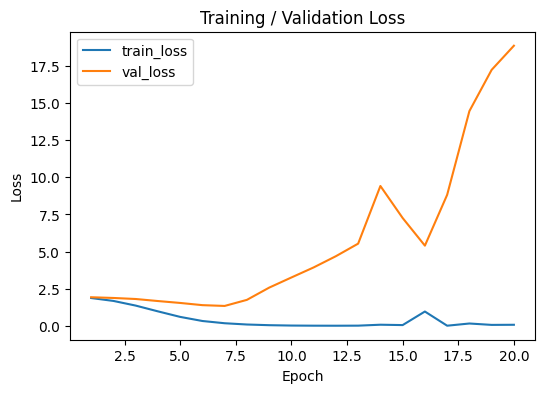

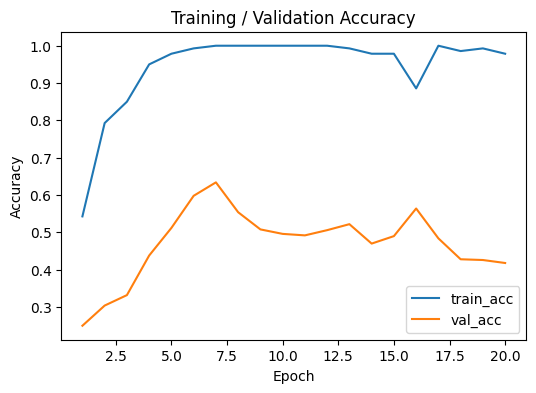

In [305]:
# =========================
# 7) Define training loop and run training
# Example here: Cora node classification
# =========================

# -------------------------------------------------
# optimizer and training settings
# -------------------------------------------------
optimizer = Adam(mpnn_model.parameters(), lr=0.01, weight_decay=5e-4)
n_epochs = 20

# -------------------------------------------------
# history containers
# -------------------------------------------------
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

# best model tracking
best_val_loss = float("inf")
best_epoch = -1
best_state = None

# -------------------------------------------------
# main training loop
# -------------------------------------------------

mpnn_model.reset_parameters() #making sure eveyrhting is fresh

for epoch in range(1, n_epochs + 1):

    # 1) train for one epoch on training nodes
    train_step_loss, train_step_acc = train_node_epoch(
        model=mpnn_model,
        data=data,
        optimizer=optimizer,
        criterion=criterion_cls,
        device=device,
    )

    # 2) evaluate current model on train and validation splits
    train_loss, train_acc = eval_node(
        model=mpnn_model,
        data=data,
        mask_name="train_mask",
        criterion=criterion_cls,
        device=device,
    )

    val_loss, val_acc = eval_node(
        model=mpnn_model,
        data=data,
        mask_name="val_mask",
        criterion=criterion_cls,
        device=device,
    )

    # 3) store history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # 4) save best model based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        best_state = copy.deepcopy(mpnn_model.state_dict())

    # 5) print progress every few epochs
    if epoch == 1 or epoch % 20 == 0 or epoch == n_epochs:
        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

# -------------------------------------------------
# load best model
# -------------------------------------------------
if best_state is not None:
    mpnn_model.load_state_dict(best_state)

print()
print(f"Best model came from epoch {best_epoch} with val_loss = {best_val_loss:.4f}")

# -------------------------------------------------
# final evaluation with best model
# -------------------------------------------------
train_loss, train_acc = eval_node(
    model=mpnn_model,
    data=data,
    mask_name="train_mask",
    criterion=criterion_cls,
    device=device,
)

val_loss, val_acc = eval_node(
    model=mpnn_model,
    data=data,
    mask_name="val_mask",
    criterion=criterion_cls,
    device=device,
)

test_loss, test_acc = eval_node(
    model=mpnn_model,
    data=data,
    mask_name="test_mask",
    criterion=criterion_cls,
    device=device,
)

print(f"Final Train -> loss: {train_loss:.4f}, acc: {train_acc:.4f}")
print(f"Final Val   -> loss: {val_loss:.4f}, acc: {val_acc:.4f}")
print(f"Final Test  -> loss: {test_loss:.4f}, acc: {test_acc:.4f}")

# -------------------------------------------------
# optional: plot training / validation curves
# -------------------------------------------------
epochs = range(1, n_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="train_loss")
plt.plot(epochs, history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_acc"], label="train_acc")
plt.plot(epochs, history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training / Validation Accuracy")
plt.legend()
plt.show()